# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [2]:
%%capture
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

## Import Libraries

In [3]:
%%capture
%pip install shap
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray
%pip install geopy
%pip install geopandas
%pip install keras-tuner

In [4]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
import shap
import pickle
from tensorflow.keras.models import load_model

#other
import os
import json

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE, TARGET_VARIABLE, MixBuf_ResNet_SelectAttr
from tools.preprocess import apply_preprocessing_mixed_buffers, load_and_preprocess_data
from tools.explainer import Explainer
from tools.build_dataset import combine_buffer_datasets

## Load Model

Here we will load our best model.

In [5]:
# get model
model_file = 'models/mixed_buffers_ResNet/mixed_buffers_ResNet_model.keras'
if os.path.exists(model_file):
  resnet_model = load_model(model_file)

# scaler
scaler_file = 'models/mixed_buffers_ResNet/mixed_buffers_standard_scaler.pkl'
with open(scaler_file, 'rb') as f:
  scaler = pickle.load(f)

## Import Datasets

Here we will import the dataset used by our best model.

In [6]:
train_combined, test_combined = combine_buffer_datasets('data/train', 'data/test')
train_combined, test_combined = apply_preprocessing_mixed_buffers(train_combined, test_combined)
selected_feature_names = MixBuf_ResNet_SelectAttr

Loading training data: data/train/50m_buffer_dataset.csv
Loading test data: data/test/50m_buffer_test_dataset.csv
Loading training data: data/train/100m_buffer_dataset.csv
Loading test data: data/test/100m_buffer_test_dataset.csv
Loading training data: data/train/150m_buffer_dataset.csv
Loading test data: data/test/150m_buffer_test_dataset.csv
Loading training data: data/train/300m_buffer_dataset.csv
Loading test data: data/test/300m_buffer_test_dataset.csv

Final Training Dataset Shape: (11229, 77)
Final Test Dataset Shape: (1040, 78)

Final Processed Training Dataset Shape: (11229, 200)
Final Processed Testing Dataset Shape: (1040, 201)


## Make Predictions

Here we will make predictions using our best model. SHAP will need them.

In [7]:
# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_combined['Longitude'].values
lat = test_combined['Latitude'].values
test_dataset = test_combined.drop(columns=['Longitude', 'Latitude'])

#select features
test_dataset = test_dataset[selected_feature_names]

#scale
x_test = pd.DataFrame(scaler.transform(test_dataset),
                      columns=test_dataset.columns,
                      index=test_dataset.index).values

# Model prediction
y_pred = resnet_model.predict(x_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


In [8]:
# combine predictions with lat and lon
loc_UHI = pd.DataFrame({
    'Longitude': lon,
    'Latitude': lat,
    'UHI Index': y_pred.flatten()
})

# In-Depth SHAP Analysis

This notebook is dedicated to performing an in-depth [**SHAP analysis**](https://shap.readthedocs.io/en/latest/) on our optimal predictive model, the **Mixed Buffer ResNet**. Although this model exhibited a slightly lower R-squared score compared to alternatives, it demonstrated reduced signs of overfitting and was more computationally efficient, with a significantly smaller file size (44 MB). Further details about the **Mixed Buffer ResNet** model, including its training process and initial evaluations, can be found in our [11_mixed_buffers_ResNet notebook](/11_mixed_buffers_RestNet.ipynb). While the previous notebook included a preliminary SHAP analysis, the present notebook aims to substantially expand upon those findings. Specifically, this comprehensive SHAP analysis will elucidate feature importance rankings, clarify the relationships between individual features and model predictions, and provide explanations for individual prediction outcomes. This analysis is crucial to gaining deeper insights into the key drivers influencing the Urban Heat Island phenomenon.



In [9]:
# Initialize SHAP Explainer for keras model depending if shap_values were precomputed
shap_vals_file = 'data/test/mixed_buffers_ResNet_shap_vals.parquet'

if os.path.exists(shap_vals_file):
  shap_values = pd.read_parquet(shap_vals_file).values
else:
  shap_values = None

explainer = Explainer(
    model=resnet_model,
    explainer_type=shap.DeepExplainer,
    X=x_test,
    feature_names=test_dataset.columns,
    ref_data=x_test,
    shap_values=shap_values
)

# save SHAP values as Parquet so we don't have to run again
shap_df = pd.DataFrame(explainer.shap_values, columns=test_dataset.columns)
shap_df.to_parquet(shap_vals_file)

## Summary Plot

Here, we will see the most important features and how do features impact predictions. This is how to interpret the plot:

- Each **dot** represents a single data point from our dataset.
- **X-Axis (`SHAP Value`)**: The **impact** of a feature on the prediction.
- **Y-Axis (Feature Names)**: The **most important features** ranked from top to bottom.
- **Color (Red to Blue)**: The **feature value** (High = Red, Low = Blue).
  - **Red** = High feature value.
  - **Blue** = Low feature value.

1. **Feature Importance**  
   - Features are **ranked by importance** (most important at the top).
   - The **wider** the spread on the X-axis, the more that feature **influences predictions**.

2. **Direction of Influence**  
   - **Positive SHAP values (Right Side)**: Feature **increases** the prediction.
   - **Negative SHAP values (Left Side)**: Feature **decreases** the prediction.

3. **Effect of Feature Value (Color Gradient)**  
   - **Red (High Value)** trends to the **right**? High values **increase** predictions.
   - **Blue (Low Value)** trends to the **left**? Low values **decrease** predictions.

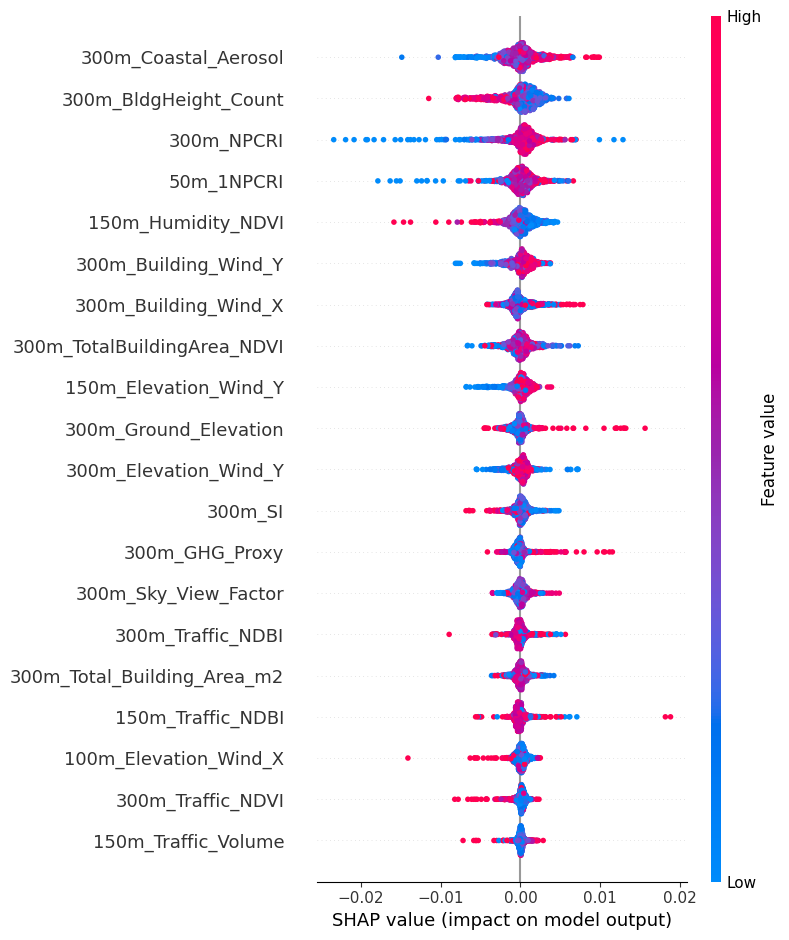

In [10]:
explainer.summary_plot()

This SHAP summary plot provides insights into how different features contribute to the predictions of your Urban Heat Island (UHI) ResNet model:

**2. Key Observations**

**A. Feature Importance**
- The most influential features (from top to bottom) include:
  - **300m_Coastal_Aerosol:** This feature shows a considerable spread in SHAP values, meaning its presence significantly influences the UHI prediction.
  - **300m_BldgHeight_Count:** Strongly impacts model output. Higher building heights generally contribute to an increase in UHI due to heat retention.
  - **300m_NPCRI & 50m_1NPCRI:** These are vegetation-related indices, suggesting that vegetation cover significantly affects the UHI effect.
  - **150m_Humidity_NDVI:** A moisture-related vegetation index, showing its role in mitigating UHI.
  - **300m_Building_Wind_X/Y:** Wind direction components indicate how airflow patterns contribute to urban temperature variations.

**B. Feature Influence (High vs. Low Values)**
  - Features with **high values** (red) generally tend to:
    - **Increase** UHI for **300m_BldgHeight_Count**, **300m_TotalBuildingArea_NDVI**, and **300m_GHG_Proxy**.
    - **Decrease** UHI for **vegetation-related indices (NPCRI, NDVI, Humidity_NDVI)**.
  
- Features with **low values** (blue) often contribute oppositely:
  - Low **vegetation indices** increase the model output, reinforcing the idea that less greenery leads to higher UHI.
  - Low **wind-related factors** lead to higher temperature retention.

**3. Interpreting Specific Feature Effects**
- **300m_Coastal_Aerosol**: May relate to air pollution, which affects heat absorption and retention.
- **Building Features (Height, Area, Wind X/Y)**: These affect heat trapping, shade, and airflow dynamics.
- **Traffic & Elevation Factors (Traffic NDBI, Traffic NDVI, Traffic Volume)**: Show how road and transportation infrastructure contribute to UHI.

**4. Practical Insights for UHI Mitigation**
- Increasing **vegetation coverage (higher NPCRI, NDVI values)** can effectively lower UHI.
- Improving **wind flow (reducing building-induced airflow obstructions)** might help dissipate heat.
- Managing **building height distribution** could control temperature buildup.

## Dependence Plot

Here we will create a Dependence Plot for all Important features for us to see the impact on UHI predictions and the interactions with other features.

### 300m Buffer Zone Coastal Aerosol

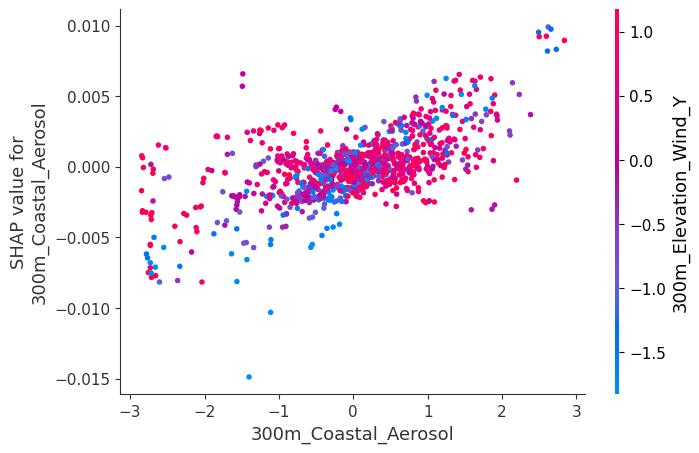

In [11]:
explainer.dependence_plot("300m_Coastal_Aerosol")

The **x-axis** represents the actual values of `300m_Coastal_Aerosol`, while the **y-axis** shows the corresponding **SHAP values**, which indicate how much this feature contributes to the model’s output. The color gradient represents **`300m_Elevation_Wind_Y`**, another interacting feature that might modify the effect of `300m_Coastal_Aerosol` on the prediction.

The **positive correlation** in the plot suggests that **higher values of `300m_Coastal_Aerosol` tend to increase the model's predictions**, while lower values often decrease them. This implies that coastal aerosol concentrations may be associated with higher UHI effects in your dataset. However, there is noticeable variance, particularly for **lower aerosol values (< -1)**, where SHAP values become more scattered, indicating some complex interactions with other factors.

The color gradient, which encodes `300m_Elevation_Wind_Y`, shows that **lower wind elevation values (blue) are associated with more negative SHAP values**, meaning that when both `300m_Coastal_Aerosol` and `300m_Elevation_Wind_Y` are low, their combined effect is to reduce the model’s predictions. Conversely, **higher wind elevation values (red) generally correspond to positive SHAP values**, indicating that when both factors are high, they contribute positively to the prediction, potentially intensifying UHI effects.

Overall, this dependence plot reveals that **`300m_Coastal_Aerosol` has a strong impact on UHI predictions, particularly when interacting with elevation-based wind patterns.** The trend suggests that areas with high aerosol levels and favorable wind conditions may experience a compounding effect, leading to stronger UHI outcomes. However, the variability in SHAP values at lower aerosol levels highlights the presence of additional influencing factors that may require further investigation.

### Interaction term: 300m Buffer Zone Building Height & Building Count

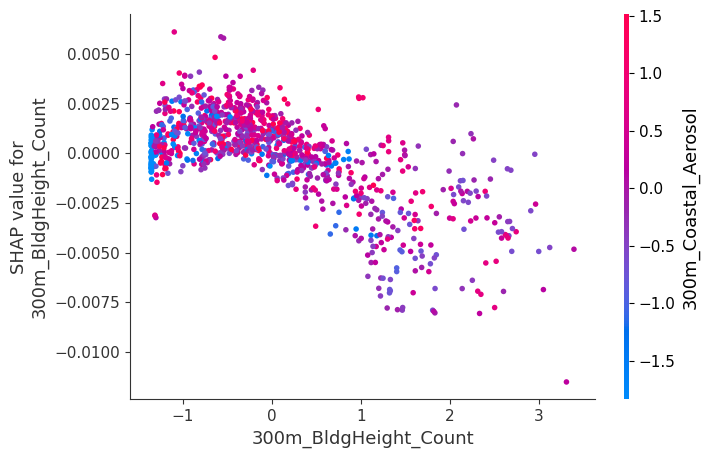

In [12]:
explainer.dependence_plot("300m_BldgHeight_Count")

This SHAP dependence plot visualizes how the feature `300m_BldgHeight_Count` (density of taller buildings in a 300m radius) influences the model’s predictions, with SHAP values indicating the magnitude and direction of impact. The x-axis represents `300m_BldgHeight_Count`, and the y-axis shows the corresponding SHAP values, revealing whether this feature increases or decreases the predicted output. At lower values (negative or near zero), the SHAP values are predominantly positive, suggesting that sparse or lower building heights contribute positively to the prediction, potentially increasing the UHI effect. However, as `300m_BldgHeight_Count` increases (higher taller building density areas), the SHAP values become negative, indicating that dense building environments lower the model output, possibly due to shading, wind flow effects, or the thermal properties of clustered urban structures. The color gradient represents the most influential variable to this attribute, `300m_Coastal_Aerosol`, showing an additional interaction where higher aerosol concentrations (red) correspond to higher SHAP values, implying that in coastal areas with more aerosols, the effect of building height density may be different. Overall, the relationship between building height count and UHI prediction is non-linear, with a clear transition from a positive to a negative SHAP impact around `300m_BldgHeight_Count ≈ 1`, suggesting a complex interaction between urban morphology and temperature dynamics.

### 300m Buffer Zone NPCRI

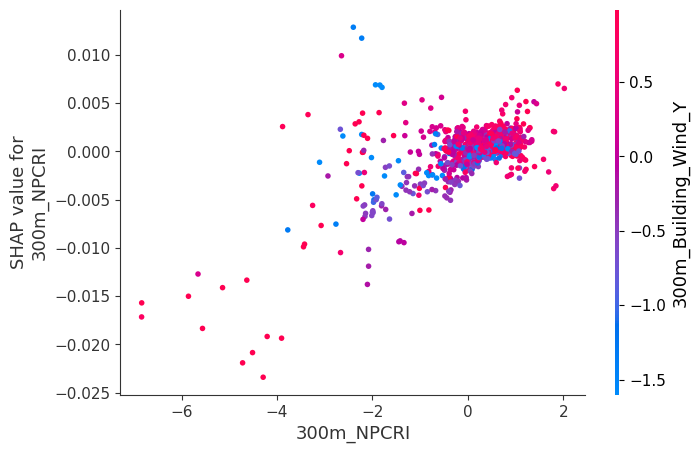

In [13]:
explainer.dependence_plot("300m_NPCRI")

The SHAP dependence plot for `300m_NPCRI` (Normalized Plant Canopy Reflectance Index) suggests a counterintuitive relationship between vegetation and the Urban Heat Island (UHI) index predicted by the model. Since our model predicts UHI index values, where any value above 1 indicates the presence of an urban heat island and values below 1 indicate cooler areas, a positive SHAP value means that the feature contributes to a higher UHI index. The plot shows that as `300m_NPCRI` increases, SHAP values also increase, indicating that locations with higher vegetation reflectance tend to have higher UHI values, meaning they are relatively warmer than the average location.

This is unexpected, as higher NPCRI typically suggests denser vegetation, which is generally associated with lower UHI effects due to shading and cooling via evapotranspiration. However, several factors could explain this trend. One possibility is that the type or distribution of vegetation in urban settings influences heat retention differently—certain types of sparse or dry vegetation might not provide significant cooling. Additionally, confounding factors such as wind flow (`300m_Building_Wind_Y`), urban density, and local microclimate variations may be influencing this relationship. Urban parks or green spaces surrounded by buildings might still retain heat due to their surroundings, offsetting the expected cooling effect of vegetation.

Overall, while higher NPCRI is generally expected to reduce UHI, our model suggests that in certain urban contexts, vegetation alone does not always mitigate heat, and other factors like wind patterns, built-up density, or specific microclimate effects might play a more dominant role. Further analysis of feature interactions or case-specific evaluations may help clarify whether this trend reflects real environmental behavior or artifacts in the data and modeling process.

### 50m Buffer Zone NPCRI

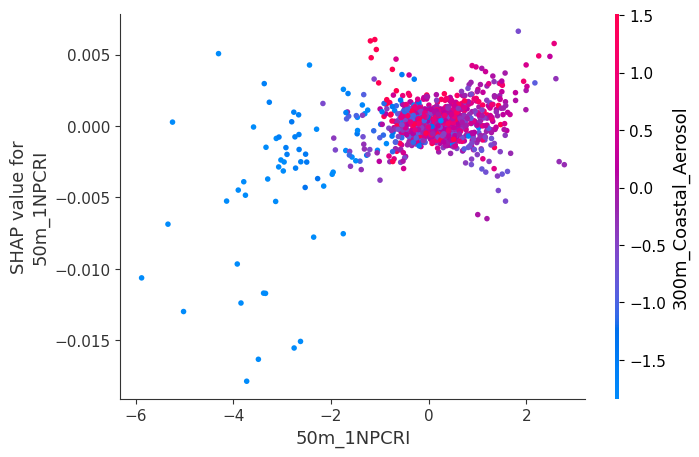

In [14]:
explainer.dependence_plot("50m_1NPCRI")

The SHAP dependence plot for `50m_1NPCRI` (a localized version of the Normalized Plant Canopy Reflectance Index at a 50m scale) reveals an interesting relationship between vegetation reflectance and the UHI index predicted by the model. The x-axis represents `50m_1NPCRI`, while the y-axis represents the SHAP values, indicating how much this feature contributes to the model’s prediction of UHI. A clear positive trend emerges—higher values of `50m_1NPCRI` correspond to higher SHAP values, suggesting that increased vegetation reflectance in smaller urban areas contributes to a higher UHI index. This suggests that areas with higher vegetation reflectance tend to be warmer than the mean temperature, similar to the relationship observed with `300m_NPCRI`.

This trend contradicts the general expectation that higher vegetation indices would correspond to lower UHI values due to cooling effects from evapotranspiration and shading. However, various factors could explain this result. One possibility is that the type of vegetation in these urban locations may not provide substantial cooling, such as sparse or dry vegetation, which might still reflect heat. Additionally, built environments surrounding these vegetation patches could trap heat, counteracting the expected cooling effect. The color gradient represents `300m_Coastal_Aerosol`, showing an interaction where areas with higher aerosol concentration (red) correspond to higher SHAP values, suggesting that airborne particles could also influence how vegetation interacts with urban heat retention.

Overall, the model suggests that increased vegetation reflectance at small scales does not necessarily lower UHI in urban areas, potentially due to microclimatic effects, the surrounding urban fabric, or the nature of the vegetation itself. Further investigation into vegetation type, density, and the role of aerosols in heat retention could provide deeper insights into why this relationship emerges in the model.

### Interaction term: 150m Buffer Zone Relative Humidity (%) & NDVI

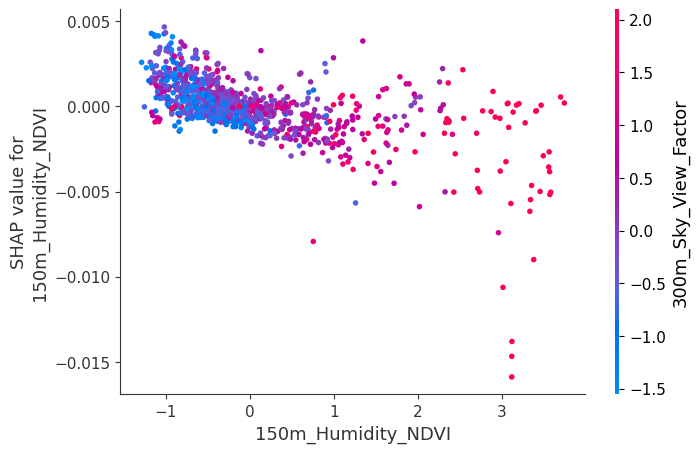

In [15]:
explainer.dependence_plot("150m_Humidity_NDVI")

The SHAP dependence plot for `150m_Humidity_NDVI`, which represents the interaction between relative humidity and the Normalized Difference Vegetation Index (NDVI) within a 150m buffer, provides key insights into its effect on the UHI index. The x-axis represents `150m_Humidity_NDVI`, while the y-axis shows the SHAP values, indicating the feature's contribution to the model’s UHI predictions. Unlike the previous vegetation-related features (`NPCRI`), this interaction term exhibits a **negative correlation** with the UHI index, as higher values of `150m_Humidity_NDVI` correspond to lower SHAP values. This suggests that areas with both higher humidity and higher vegetation coverage contribute to lower UHI, meaning they help cool the environment.

At lower values of `150m_Humidity_NDVI` (near -1 or 0), the SHAP values are closer to zero or slightly positive, implying that areas with low humidity and sparse vegetation have a neutral to slightly warming effect on UHI. However, as `150m_Humidity_NDVI` increases beyond 1, the SHAP values decrease, indicating that the model predicts lower UHI index values in regions where both vegetation and humidity are present. This aligns with expectations since higher vegetation cover combined with moisture availability should enhance cooling through evapotranspiration.

The color gradient represents `300m_Sky_View_Factor`, which measures the proportion of sky visible from the ground. Notably, **high sky view factor values (red) are associated with stronger cooling effects (more negative SHAP values)**, suggesting that open areas with greater sky exposure and humidity-vegetation interactions contribute to reducing UHI. Conversely, **lower sky view factor values (blue) correspond to less negative SHAP values**, implying that in denser urban environments, even with high humidity and vegetation, the cooling effect may be reduced due to obstructed airflow and heat retention by surrounding buildings.

In summary, this plot reinforces the idea that **urban areas with both vegetation and moisture availability exhibit a cooling effect on UHI, particularly when combined with open spaces that allow for effective heat dissipation**. The interaction between **humidity and NDVI plays a significant role in mitigating urban heat, and areas with a high sky view factor amplify this cooling benefit**. Further analysis could explore how different urban layouts influence this effect, particularly in varying levels of vegetation density and building obstruction.

### Interaction term: 300m Buffer Zone Building Height, Avg Wind Speed (m/s), & North-South Wind Component

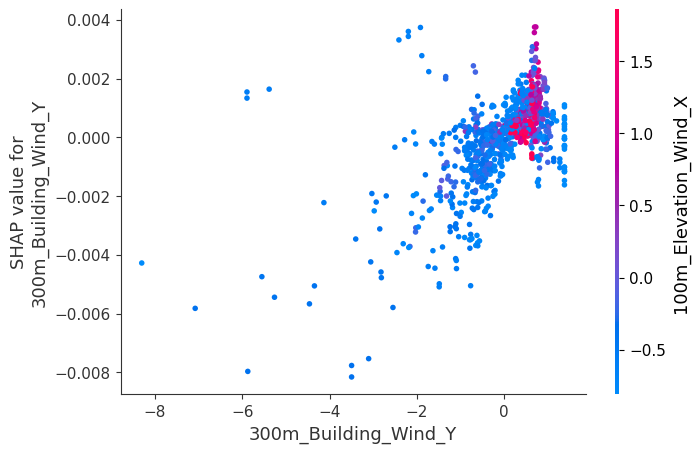

In [16]:
explainer.dependence_plot("300m_Building_Wind_Y")

The SHAP dependence plot for `300m_Building_Wind_Y` illustrates how the interaction between **building height, average wind speed, and the north-south wind component** at a 300m scale influences the UHI index predictions. The x-axis represents `300m_Building_Wind_Y`, while the y-axis represents the corresponding SHAP values, indicating whether this feature increases or decreases the model’s UHI prediction. A clear trend emerges where lower values of `300m_Building_Wind_Y` (negative values) are associated with **strongly negative SHAP values**, suggesting that when north-south wind flow is lower (or predominantly north-south), the model predicts a cooling effect on UHI. However, as `300m_Building_Wind_Y` increases toward zero and beyond, SHAP values cluster closer to zero or slightly positive, meaning weaker wind flows or north-south winds correlate with a smaller or even slightly increasing impact on UHI.

This pattern indicates that **strong north-south winds contribute to cooling the urban environment**, possibly due to enhanced airflow reducing heat retention around buildings. In contrast, areas where wind speeds are lower or predominantly north-south show less cooling influence, possibly due to stagnation, where warm air remains trapped within urban structures.

The color gradient represents `100m_Elevation_Wind_X`, which captures the wind speed in the **east-west direction** at a finer 100m scale. Notably, **higher `100m_Elevation_Wind_X` values (red) are clustered at the higher end of `300m_Building_Wind_Y`**, suggesting that when east-west wind speeds are stronger, the north-south wind component’s impact on UHI is reduced or neutralized. Conversely, **lower `100m_Elevation_Wind_X` values (blue) are more dispersed at lower `300m_Building_Wind_Y` values**, reinforcing the idea that weak overall wind speeds combined with specific north-south flow patterns can strongly influence urban heat retention.

In summary, this plot suggests that **north-south winds at a 300m scale play a critical role in mitigating UHI, likely by enhancing airflow and dissipating heat in urban areas**. However, in areas with weak wind activity, especially where north-south winds dominate, urban heat effects may be more pronounced due to reduced ventilation. Additionally, east-west wind components interact with this effect, influencing how urban structures and elevation patterns shape wind flow dynamics. Understanding these wind-building interactions is crucial for urban planning strategies aimed at leveraging wind corridors to reduce heat buildup in dense city environments.

### Interaction term: 300m Buffer Zone Building Height, Avg Wind Speed (m/s), & East-West Wind Component

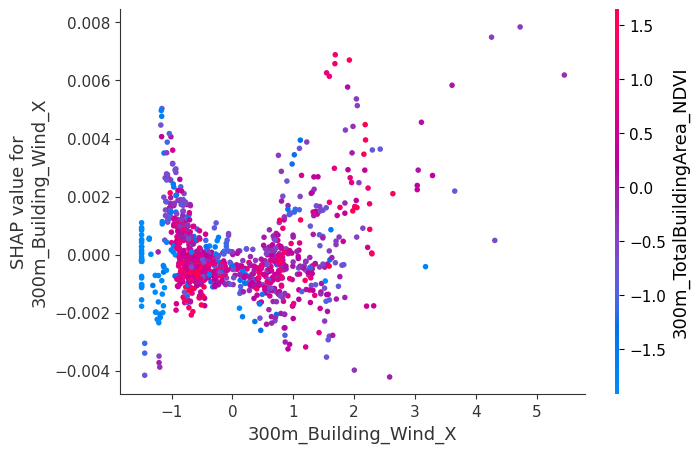

In [17]:
explainer.dependence_plot("300m_Building_Wind_X")

The SHAP dependence plot for `300m_Building_Wind_X` represents the interaction between **building height, average wind speed, and the east-west wind component** at a 300m scale and its impact on the UHI index predictions. The x-axis corresponds to `300m_Building_Wind_X`, while the y-axis shows the SHAP values, indicating the influence of this feature on the model’s output. The plot suggests a **nonlinear relationship**, with SHAP values clustering around zero for most values but showing increased variability for both **very low and very high values of `300m_Building_Wind_X`**.

For negative values of `300m_Building_Wind_X` (indicating predominantly westward wind flow), the SHAP values are mostly close to zero or slightly negative, suggesting that strong westward winds do not significantly increase UHI and may even contribute to a cooling effect. As `300m_Building_Wind_X` approaches zero (indicating weak or stagnant east-west winds), the SHAP values remain close to zero, implying that when east-west wind speeds are low, their impact on UHI predictions is minimal. However, for **higher positive values of `300m_Building_Wind_X`** (indicating stronger eastward wind flow), the SHAP values show greater spread, with some points contributing positively to UHI, indicating that in certain cases, stronger eastward winds may lead to localized warming.

The color gradient represents `300m_TotalBuildingArea_NDVI`, which combines total built-up area with vegetation indices. Notably, **higher `300m_TotalBuildingArea_NDVI` values (red) are associated with more positive SHAP values**, indicating that in areas where urban development is combined with some vegetation, east-west winds might contribute to heat retention rather than dissipation. Conversely, **lower `300m_TotalBuildingArea_NDVI` values (blue) appear in both extremes of wind flow**, suggesting that in areas with minimal building coverage or limited vegetation, the impact of wind on UHI is more variable.

In summary, this plot suggests that **east-west wind patterns interact with urban form in a complex way**. **Stronger eastward winds can, in some cases, contribute to UHI, particularly in areas with built-up environments that retain heat**. Meanwhile, **westward winds appear to have a more neutral or slightly cooling effect**, likely due to their role in ventilating heat away from urban surfaces. The presence of vegetation within built-up areas modifies this relationship, emphasizing the importance of urban design in optimizing airflow to reduce heat accumulation. Further analysis could examine how built-up density and green infrastructure influence wind-driven heat dispersion in urban environments.

### Interaction term: 300m Buffer Zone Total Building Area (m^2) & NDVI

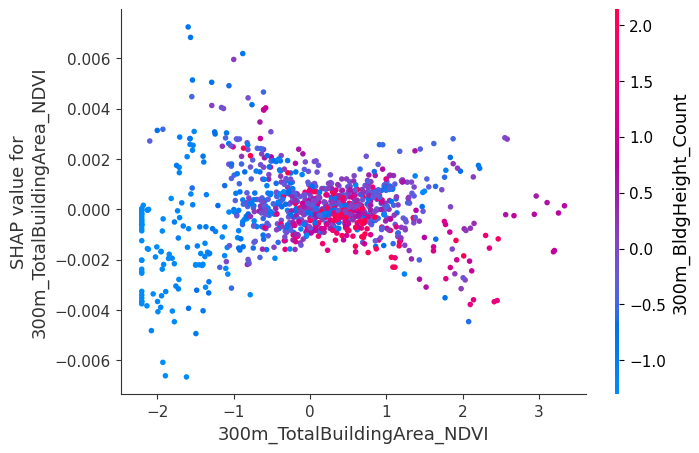

In [18]:
explainer.dependence_plot("300m_TotalBuildingArea_NDVI")

The SHAP dependence plot for `300m_TotalBuildingArea_NDVI` explores the interaction between **total building area (m²) and vegetation cover (NDVI) within a 300m buffer** and its influence on the UHI index predictions. The x-axis represents `300m_TotalBuildingArea_NDVI`, while the y-axis shows the corresponding SHAP values, indicating how much this feature contributes to the model’s UHI predictions. The trend in this plot suggests that **areas with low `300m_TotalBuildingArea_NDVI` values (negative values) tend to have more negative SHAP values, indicating a cooling effect**, while areas with moderate to high values exhibit a more neutral or slightly positive effect on UHI.

For **negative values of `300m_TotalBuildingArea_NDVI`**, the SHAP values are predominantly negative, implying that locations with **lower built-up area and potentially more vegetation coverage contribute to cooling**. This aligns with expectations, as **lower building density combined with higher vegetation cover should mitigate urban heat**. However, as `300m_TotalBuildingArea_NDVI` moves toward **zero and positive values (higher built-up density with vegetation presence)**, the SHAP values tend to cluster around zero, indicating a diminished influence on the UHI index.

The color gradient represents `300m_BldgHeight_Count`, which accounts for the **number of buildings within a 300m buffer**. Interestingly, **higher `300m_BldgHeight_Count` values (red) appear more frequently in areas with neutral to slightly positive SHAP values**, suggesting that **in areas with more buildings, even when vegetation is present, the UHI mitigation effect may be weaker or counteracted by the heat-retaining properties of buildings**. Conversely, **lower building count values (blue) are more associated with negative SHAP values**, reinforcing the idea that areas with more open land and vegetation exert a cooling influence.

Overall, this plot suggests that **while vegetation can reduce UHI, its effectiveness is influenced by the surrounding built environment**. Areas with a mix of **higher building area and NDVI do not show strong cooling effects**, likely due to urban heat retention despite vegetation presence. On the other hand, **areas with low built-up area and more vegetation contribute more significantly to reducing UHI**. This insight highlights the importance of balancing urban development with sufficient green space to enhance the cooling potential of vegetation, particularly in densely built environments. Further analysis could examine the threshold at which vegetation is no longer effective in mitigating heat due to excessive urban density.

### Interaction term: 150m Buffer Zone Ground Elevation, Avg Wind Speed (m/s), & North-South Wind Component

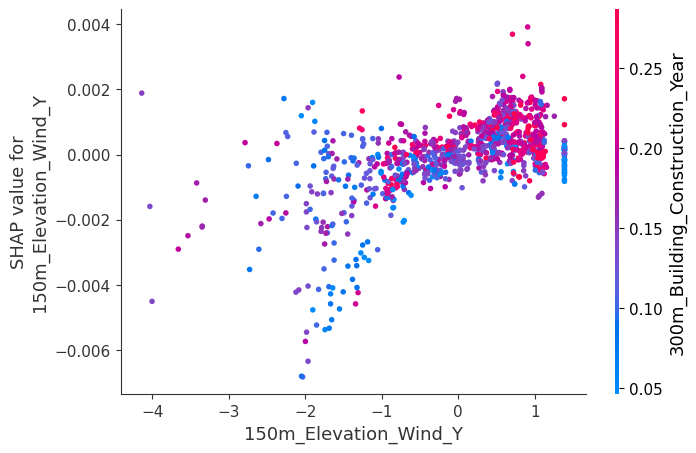

In [19]:
explainer.dependence_plot("150m_Elevation_Wind_Y")

The SHAP dependence plot for `150m_Elevation_Wind_Y` captures the interaction between **ground elevation, average wind speed, and the north-south wind component within a 150m buffer** and its impact on the UHI index predictions. The x-axis represents `150m_Elevation_Wind_Y`, while the y-axis shows the corresponding SHAP values, indicating how much this feature contributes to the model’s UHI predictions.

The plot shows a **positive correlation**, where higher values of `150m_Elevation_Wind_Y` (indicating stronger north-south winds at a higher elevation) correspond to **higher SHAP values**, meaning that these conditions **increase UHI index predictions**. Conversely, lower values of `150m_Elevation_Wind_Y` (indicating weaker north-south winds at a lower elevation) tend to have **negative SHAP values**, suggesting a cooling effect. This implies that **weaker north-south wind movement at a lower elevation is more effective at mitigating UHI**, potentially by promoting better air circulation and cooling in urban areas, whereas **stronger north-south winds at a higher elevation may be associated with heat stagnation or reduced airflow efficiency** in certain urban settings.

The color gradient represents `300m_Building_Construction_Year`, which provides insight into the average age of buildings within a 300m radius. Notably, **older buildings (blue) appear more frequently at lower `150m_Elevation_Wind_Y` values**, where the SHAP values are negative, reinforcing the idea that areas with older structures and weaker north-south winds at a lower elevation experience more cooling. On the other hand, **newer buildings (red) are more concentrated at higher `150m_Elevation_Wind_Y` values**, suggesting that **recently constructed urban developments may be more prone to UHI effects, especially when influenced by stronger north-south winds at a higher elevation**. This could be due to modern materials with higher heat retention properties, increased urban density, or differences in ventilation patterns.

Overall, this plot suggests that **wind flow direction and elevation significantly influence UHI**. Additionally, the **age of urban infrastructure interacts with this effect, with older urban areas experiencing more cooling under favorable wind conditions, whereas newer developments may be more susceptible to UHI intensification**. This highlights the importance of **urban planning strategies that incorporate wind flow management, building materials, and open spaces to optimize natural cooling mechanisms in high-risk UHI zones**. Further investigation into specific urban layouts and their wind dynamics could provide deeper insights into designing climate-responsive cities.

### 300m Buffer Zone Ground Elevation

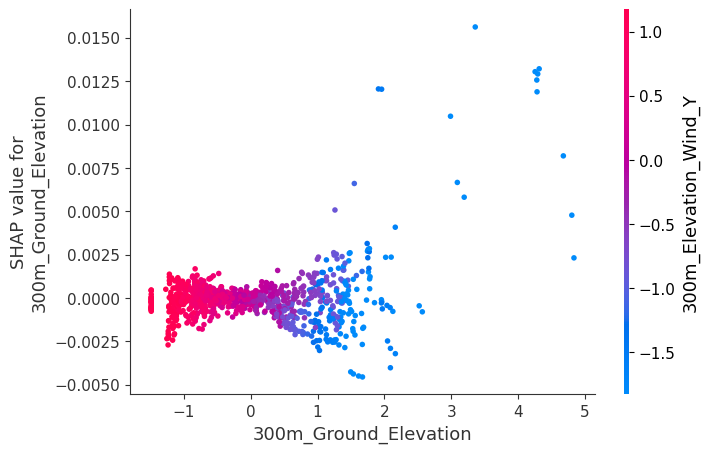

In [20]:
explainer.dependence_plot("300m_Ground_Elevation")

The SHAP dependence plot for `300m_Ground_Elevation` illustrates the relationship between **ground elevation within a 300m buffer** and its impact on the UHI index predictions. The x-axis represents `300m_Ground_Elevation`, while the y-axis displays the corresponding SHAP values, indicating whether this feature increases or decreases the UHI index.

The plot shows a **nonlinear relationship**, where **lower elevation values (negative and near-zero values) are associated with neutral or slightly positive SHAP values**, suggesting that **low-elevation areas tend to contribute to UHI**. However, as elevation increases beyond **approximately 1 to 2**, SHAP values trend **negative**, implying that higher elevations tend to **reduce UHI effects**. This trend is consistent with known urban heat dynamics, as **higher-elevation areas often experience better air circulation, lower heat retention, and reduced urban density compared to lower-elevation regions, which are more prone to heat buildup**.

The color gradient represents `300m_Elevation_Wind_Y`, capturing the **north-south wind component** in relation to elevation. Notably, **lower elevation values are predominantly associated with higher `300m_Elevation_Wind_Y` values (red)**, suggesting that **in low-elevation areas, wind conditions may be weaker or predominantly north-south, limiting heat dissipation and leading to stronger UHI effects**. Conversely, **higher elevations tend to be associated with lower `300m_Elevation_Wind_Y` values (blue), meaning these regions experience stronger north-south winds, which likely enhance cooling and reduce UHI**.

In summary, this plot suggests that **ground elevation plays a crucial role in urban heat dynamics, with higher elevations generally mitigating UHI due to improved ventilation and reduced heat retention, while lower elevations are more susceptible to heat accumulation**. Additionally, **wind interactions at different elevations influence this relationship**, with lower-elevation areas exhibiting wind conditions that may exacerbate UHI effects. This insight highlights the importance of considering topography and wind flow patterns in urban planning to mitigate heat island effects, particularly in densely built low-lying areas that may require additional cooling strategies such as increased vegetation or enhanced airflow management.

### Interaction term: 300m Buffer Zone Ground Elevation, Avg Wind Speed (m/s), & North-South Wind Component

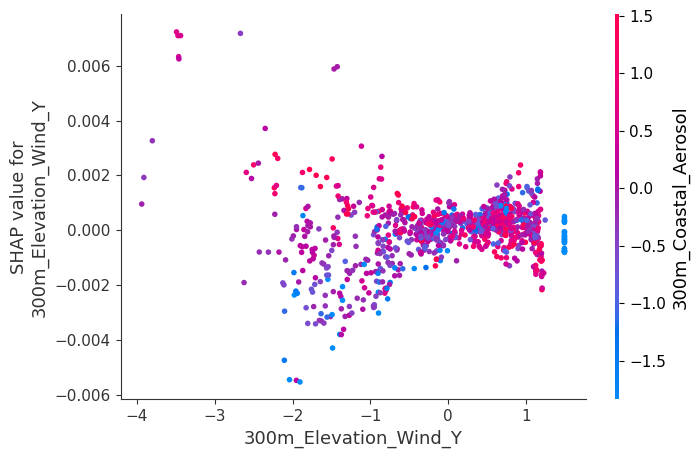

In [21]:
explainer.dependence_plot("300m_Elevation_Wind_Y")

The SHAP dependence plot for `300m_Elevation_Wind_Y` explores the interaction between **ground elevation, average wind speed, and the north-south wind component within a 300m buffer** and its influence on the UHI index predictions. The x-axis represents `300m_Elevation_Wind_Y`, while the y-axis shows the corresponding SHAP values, indicating whether this feature increases or decreases the model’s predicted UHI index.

The plot exhibits a **nonlinear trend**, where **negative values of `300m_Elevation_Wind_Y` (indicating lower elevation and weaker north-south winds) are associated with both positive/negative SHAP values**, meaning that **lower elevation and weaker north-south winds don't linearly contribute to increasing/decresing UHI effects**. Conversely, **as `300m_Elevation_Wind_Y` approaches zero or becomes positive (indicating stronger winds or higher elevation), SHAP values cluster around neutral or slightly positive values**, suggesting that **stronger wind circulation or higher elevation does not significantly mitigate UHI and may even contribute to heat retention**.

The color gradient represents `300m_Coastal_Aerosol`, which indicates the presence of airborne particles in the atmosphere, particularly in coastal environments. Interestingly, **higher aerosol concentrations (red) are more frequently associated with neutral to positive SHAP values**, suggesting that **areas with more aerosols tend to have a weaker cooling effect, possibly due to increased heat absorption by particulate matter or reduced wind efficiency in dispersing heat**. On the other hand, **lower aerosol concentrations (blue) correspond to more negative SHAP values, reinforcing the idea that cleaner air may allow for more effective cooling via wind circulation**.

### 300m Buffer Zone SI

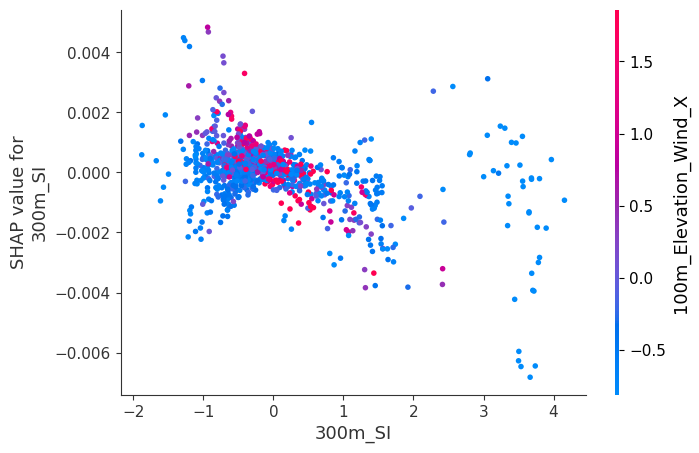

In [22]:
explainer.dependence_plot("300m_SI")

The SHAP dependence plot for `300m_SI` (Shadow Index) illustrates how **shadow density within a 300m buffer** affects the UHI index predictions. The x-axis represents `300m_SI`, while the y-axis shows the corresponding SHAP values, indicating how this feature contributes to the model’s UHI predictions.

The plot reveals a **negative correlation between `300m_SI` and SHAP values**, meaning that **higher shadow index values (more shadow coverage) tend to reduce UHI**, whereas lower shadow index values (less shadow coverage) contribute to **higher UHI effects**. This aligns with the expectation that **greater shadow coverage, likely from buildings and vegetation, provides natural cooling by reducing direct solar exposure, thereby mitigating UHI impacts**. Conversely, areas with **low shadow index values (indicating high sun exposure due to less obstruction) retain more heat, leading to higher UHI intensities**.

The color gradient represents `100m_Elevation_Wind_X`, which captures the **east-west wind component at a finer 100m scale**. **Higher `100m_Elevation_Wind_X` values (red) are clustered in regions with low or moderate `300m_SI` values**, suggesting that areas with **less shadow coverage but stronger east-west winds may experience mixed UHI effects**, where wind flow could either exacerbate or reduce heat retention. On the other hand, **lower `100m_Elevation_Wind_X` values (blue) are more dispersed in high `300m_SI` regions**, indicating that **in areas with more shadow coverage, weaker wind speeds may still be sufficient to provide cooling**.

Overall, this plot suggests that **shadow coverage plays a crucial role in mitigating UHI, with higher shadow index values contributing to lower urban heat effects**. Additionally, **wind direction interacts with shadow coverage, potentially modifying the cooling effects of shaded environments**. These findings emphasize the importance of **urban planning strategies that enhance shading through vegetation and architectural design, particularly in areas where wind-driven cooling is limited**. Further analysis could explore **optimal shadow-to-wind interactions to maximize heat mitigation in urban environments**.

### Interaction term: 300m Buffer Zone Building Count, Traffic Volume, & Solar Flux (W/m^2)

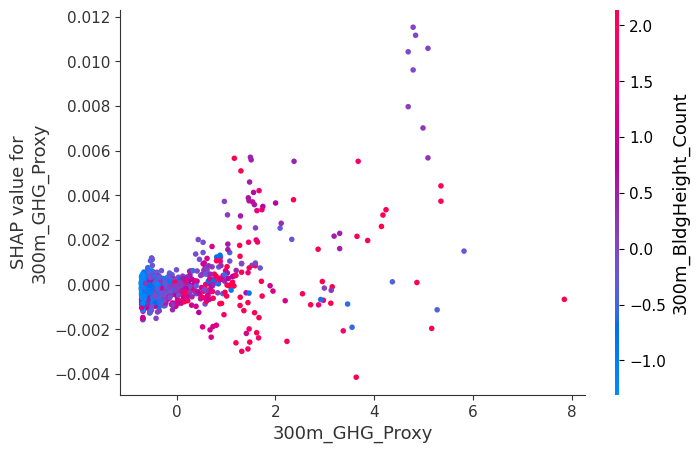

In [23]:
explainer.dependence_plot("300m_GHG_Proxy")

The SHAP dependence plot for `300m_GHG_Proxy` illustrates how **greenhouse gas (GHG) concentration within a 300m buffer**, influenced by **building count, traffic volume, and solar flux (W/m²)**, impacts the UHI index predictions. The x-axis represents `300m_GHG_Proxy`, while the y-axis displays the corresponding SHAP values, showing how this feature contributes to the model’s predictions.

The plot suggests a **positive correlation between `300m_GHG_Proxy` and SHAP values**, meaning that **higher levels of GHG emissions tend to increase UHI index predictions**, which aligns with expectations since greenhouse gases trap heat and contribute to temperature rise in urban environments. At **lower values of `300m_GHG_Proxy` (close to zero), SHAP values cluster around zero or slightly negative**, indicating that **areas with minimal GHG emissions do not significantly contribute to UHI or may even exhibit cooling effects**. However, as `300m_GHG_Proxy` increases, SHAP values become increasingly positive, confirming that **GHG-heavy urban zones are associated with intensified heat retention and higher UHI effects**.

The color gradient represents `300m_BldgHeight_Count`, which reflects the **density of buildings in the 300m buffer**. Notably, **higher building count values (red) are more common at elevated GHG levels, reinforcing the link between dense urbanization and increased UHI intensity**. This suggests that **areas with more buildings tend to generate and trap more greenhouse gases, exacerbating urban heat accumulation**. Conversely, **lower building count values (blue) are associated with lower `300m_GHG_Proxy` values, supporting the idea that less built-up areas experience lower heat retention effects**.

Overall, this plot provides strong evidence that **higher GHG concentrations, particularly in densely built environments with high traffic volume and solar exposure, significantly contribute to UHI effects**. This highlights the importance of **mitigating greenhouse gas emissions through urban design strategies such as green infrastructure, improved traffic management, and energy-efficient buildings**. Additionally, the interaction with building height suggests that **taller, denser urban developments may exacerbate heat retention when combined with high GHG emissions**, underscoring the need for sustainable urban planning approaches to counteract UHI intensification.

### 300m Buffer Zone 1 - Building Density

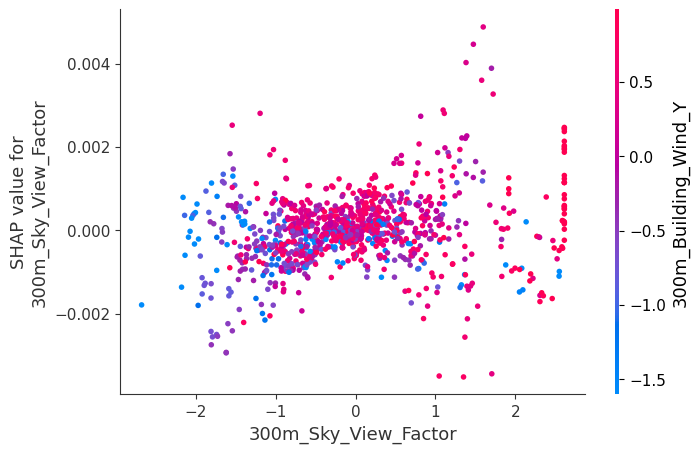

In [24]:
explainer.dependence_plot("300m_Sky_View_Factor")

The SHAP dependence plot for `300m_Sky_View_Factor` (engineered as **1 - building density**) explores how **urban openness and visibility of the sky within a 300m buffer** influence the UHI index predictions. The x-axis represents `300m_Sky_View_Factor`, while the y-axis displays the corresponding SHAP values, indicating how this feature contributes to the model’s UHI predictions.

The plot shows a **mildly positive correlation**, suggesting that **higher `300m_Sky_View_Factor` values (indicating more open spaces and lower building density) slightly increase UHI index predictions**. This is somewhat counterintuitive, as areas with a **higher sky view factor are expected to have better natural cooling due to improved airflow and radiative heat dissipation**. However, the **spread of SHAP values remains relatively tight around zero**, indicating that this feature has **a minor overall influence on UHI relative to other urban morphology factors**.

### Interaction term: 300m Buffer Zone Traffic Volume & NDBI

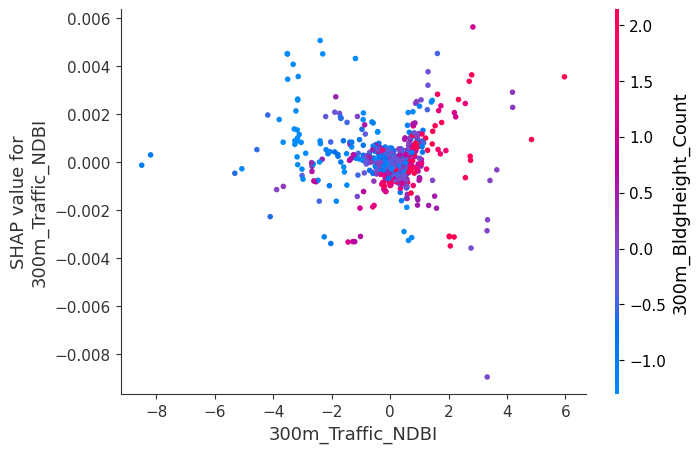

In [25]:
 explainer.dependence_plot("300m_Traffic_NDBI")

The SHAP dependence plot for `300m_Traffic_NDBI` examines the interaction between **traffic volume and the Normalized Difference Built-up Index (NDBI) within a 300m buffer** and its impact on the UHI index predictions. The x-axis represents `300m_Traffic_NDBI`, while the y-axis shows the corresponding SHAP values, indicating how this feature contributes to the model’s UHI predictions.

The plot does not exhibit a **strong linear correlation**, with SHAP values clustering near **zero**, suggesting that **traffic-related built-up intensity has a relatively minor impact on UHI predictions compared to other urban features**. However, there is a slight **positive trend**, meaning that **higher `300m_Traffic_NDBI` values (indicating areas with more traffic and a higher proportion of built surfaces) tend to increase the UHI index slightly**. This aligns with expectations, as **traffic contributes to heat emissions from vehicles, and built-up surfaces (measured by NDBI) retain heat, both factors leading to localized warming**.

At **lower `300m_Traffic_NDBI` values (negative or near zero)**, SHAP values tend to remain close to zero or slightly negative, indicating that **areas with lower traffic volume and less built-up intensity do not significantly contribute to UHI or may even experience slight cooling effects**. However, at **higher values of `300m_Traffic_NDBI`**, the spread of SHAP values increases, suggesting that in some high-traffic, highly built-up areas, the UHI impact is more pronounced.

The color gradient represents `300m_BldgHeight_Count`, capturing the **density of buildings in the surrounding area**. **Higher building height count values (red) are more concentrated at moderate to high `300m_Traffic_NDBI` values**, suggesting that **in areas where traffic and built-up intensity are high, greater building density may further amplify UHI effects by restricting airflow and increasing heat retention**. Conversely, **lower building height count values (blue) are more scattered across the lower range of `300m_Traffic_NDBI` values**, reinforcing the idea that in areas with less development and lower traffic volume, UHI effects remain minimal.

Overall, this plot suggests that **while traffic and built-up intensity contribute to UHI, their impact is relatively moderate compared to other urban features such as vegetation, wind dynamics, and building height**. However, **the combination of high traffic, extensive built-up surfaces, and tall buildings may create localized heat traps, reinforcing UHI effects**. This highlights the importance of **urban cooling strategies such as increased vegetation near roads, heat-reflective building materials, and improved urban ventilation to mitigate heat accumulation in high-traffic zones**. Further investigation into the specific role of traffic emissions versus built-up intensity could provide deeper insights into effective UHI reduction strategies in dense urban environments.

### 300m Buffer Zone Total Building Area (m^2)

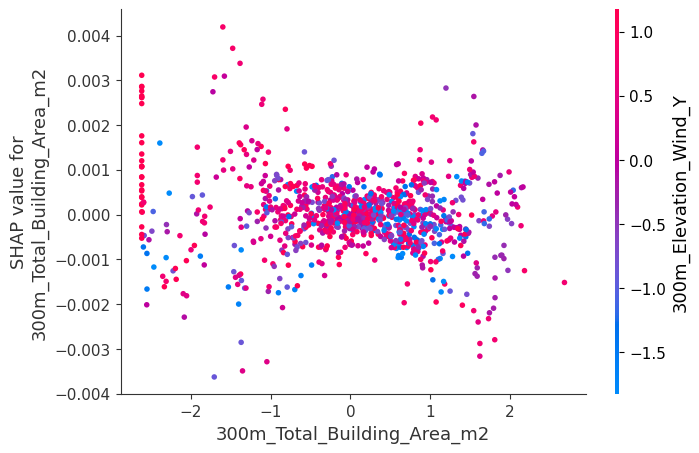

In [26]:
explainer.dependence_plot("300m_Total_Building_Area_m2")

The SHAP dependence plot for `300m_Total_Building_Area_m2` examines the relationship between **total building area within a 300m buffer** and its impact on the UHI index predictions. The x-axis represents `300m_Total_Building_Area_m2`, while the y-axis shows the corresponding SHAP values, indicating how this feature influences the model’s UHI predictions.

The plot suggests a **weak correlation** between `300m_Total_Building_Area_m2` and UHI, as SHAP values remain **tightly clustered around zero** across different building area values. This indicates that **total building area alone does not strongly influence UHI predictions** in the model. However, **there is some variation in SHAP values at both extremes of building area**, suggesting that in specific cases, **higher total building area may slightly contribute to an increase in UHI**.

At **lower values of `300m_Total_Building_Area_m2` (negative and near-zero values)**, SHAP values are scattered between slightly negative and neutral, suggesting that **areas with low total building area either do not contribute significantly to UHI or might exhibit slight cooling effects**. Conversely, at **higher values of `300m_Total_Building_Area_m2`**, there is a slightly increased spread of positive SHAP values, indicating that **very dense urban areas with large total building footprints may contribute to localized heat accumulation**.

The color gradient represents `300m_Elevation_Wind_Y`, capturing the **north-south wind component in the area**. **Higher `300m_Elevation_Wind_Y` values (red) are more concentrated at moderate to high building area values**, suggesting that **in areas with extensive built-up space, wind conditions may have a modifying effect on UHI, potentially counteracting or amplifying heat retention**. Conversely, **lower `300m_Elevation_Wind_Y` values (blue) appear at both extremes**, suggesting that in both low- and high-building area environments, wind conditions vary significantly and can influence how heat is distributed.

Overall, this plot suggests that **total building area within a 300m buffer alone does not serve as a strong predictor of UHI, but in certain contexts—especially in dense urban environments—it can contribute to localized heating effects**. Additionally, the interaction with wind dynamics highlights that **natural ventilation plays a role in shaping UHI intensity, even in highly built-up areas**. This underscores the importance of **considering urban design strategies that balance built space with green infrastructure and optimized wind flow to mitigate heat retention in high-density environments**. Further analysis could explore how **building area interacts with other factors such as vegetation, material reflectivity, and height distribution to provide more targeted UHI mitigation strategies**.

### Interaction term: 150m Buffer Zone Traffic Volume & NDBI

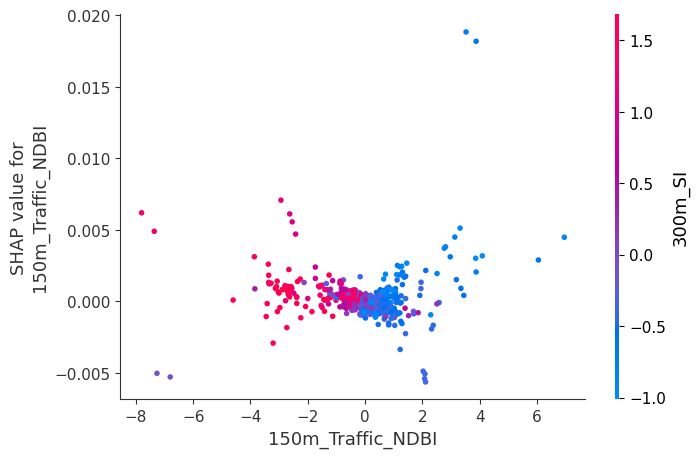

In [27]:
explainer.dependence_plot("150m_Traffic_NDBI")

The SHAP dependence plot for `150m_Traffic_NDBI` explores the interaction between **traffic volume and the Normalized Difference Built-up Index (NDBI) within a 150m buffer** and its influence on the UHI index predictions. The x-axis represents `150m_Traffic_NDBI`, while the y-axis displays the corresponding SHAP values, indicating how this feature contributes to the model’s UHI predictions.

The plot reveals a **weak overall correlation** between `150m_Traffic_NDBI` and UHI, as SHAP values remain **clustered around zero** for most of the range. This suggests that **traffic-related built-up intensity has only a minor impact on UHI predictions in the model**. However, at **extreme values of `150m_Traffic_NDBI` (both highly negative and highly positive values), the SHAP values show greater variation**, implying that in **some localized cases, high or low traffic density combined with built-up areas can either amplify or mitigate UHI effects**.

At **negative `150m_Traffic_NDBI` values**, SHAP values are more widely spread, with both positive and negative influences on UHI. This suggests that **in areas with lower traffic volume and lower built-up intensity, UHI impacts are highly variable**, possibly depending on additional factors such as wind, vegetation, or shading effects. Conversely, at **positive `150m_Traffic_NDBI` values (higher traffic and built-up density), SHAP values tend to be slightly positive**, indicating that **increased traffic and dense urban surfaces contribute somewhat to UHI intensity**—though the effect is relatively small compared to other features.

The color gradient represents `300m_SI` (Shadow Index), which measures the amount of shading from buildings and vegetation within a 300m buffer. **Higher shadow index values (red) appear more frequently at lower `150m_Traffic_NDBI` values**, suggesting that **in areas with lower traffic and built-up intensity, shading effects might be more prominent, potentially mitigating UHI effects**. Conversely, **lower shadow index values (blue) are more common at higher `150m_Traffic_NDBI` values**, reinforcing the idea that **in dense, high-traffic areas with minimal shading, UHI effects are more likely to be exacerbated**.

Overall, this plot suggests that **while traffic volume and built-up intensity play a role in UHI, their influence is relatively minor compared to other factors such as vegetation, shading, and wind dynamics**. However, **localized effects may emerge in areas where traffic and built-up density are extremely high or low**, highlighting the need for **integrated urban planning solutions that consider shading, ventilation, and surface materials to mitigate UHI in high-traffic zones**. Further analysis could explore how traffic emissions interact with building density and shadow effects to refine UHI mitigation strategies in urban environments.

### Interaction term: 100m Buffer Zone Ground Elevation, Avg Wind Speed (m/s), & East-West Wind Component

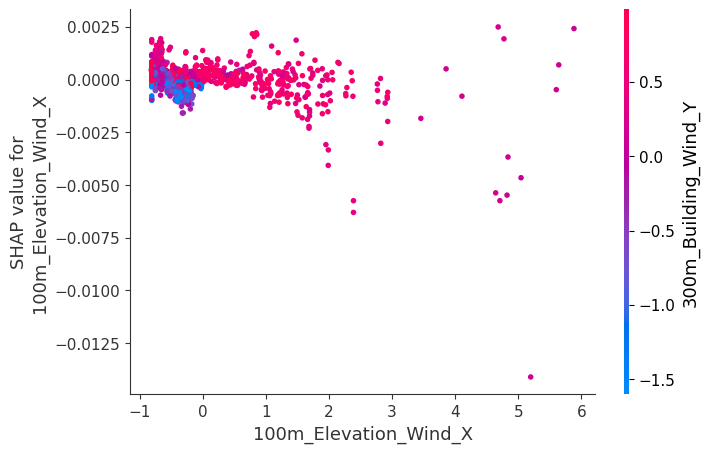

In [28]:
explainer.dependence_plot("100m_Elevation_Wind_X")

The SHAP dependence plot for `100m_Elevation_Wind_X` examines the interaction between **ground elevation, average wind speed, and the east-west wind component within a 100m buffer** and its influence on the UHI index predictions. The x-axis represents `100m_Elevation_Wind_X`, while the y-axis shows the corresponding SHAP values, indicating how this feature contributes to the model’s UHI predictions.

The plot suggests a **nonlinear relationship**, with **most data points clustering around zero SHAP values**, indicating that **east-west wind flow at a fine spatial scale has a relatively minor overall impact on UHI predictions**. However, at **higher `100m_Elevation_Wind_X` values (above ~2)**, the spread of SHAP values increases, with some negative SHAP values emerging, suggesting that **in certain cases, strong eastward winds contribute to cooling and reduce UHI intensity**. Conversely, at **lower values of `100m_Elevation_Wind_X` (near or below zero)**, SHAP values remain predominantly neutral, indicating that **weaker or east-west winds have a limited influence on the model’s UHI predictions**.

The color gradient represents `300m_Building_Wind_Y`, which measures the **north-south wind component within a 300m buffer**. Notably, **higher `300m_Building_Wind_Y` values (red) appear more frequently at moderate to high `100m_Elevation_Wind_X` values**, suggesting that **areas with stronger eastward winds often coincide with areas experiencing north-south wind effects, potentially influencing heat dispersion patterns**. Conversely, **lower `300m_Building_Wind_Y` values (blue) are more scattered, indicating that in areas with weaker north-south wind flow, east-west wind effects are more varied and may be less consistent in their impact on UHI**.

Overall, this plot suggests that **while east-west wind dynamics at a localized 100m scale do not have a strong direct effect on UHI, stronger east-west winds in specific cases may contribute to cooling effects**. Additionally, **interactions with larger-scale north-south wind dynamics play a role in shaping UHI outcomes**, reinforcing the importance of **considering multi-directional wind flow in urban climate modeling**. This highlights the need for **integrated urban ventilation planning strategies that optimize both east-west and north-south wind corridors to improve heat dispersion and mitigate UHI effects**. Further exploration could focus on **how terrain and building density modify wind-driven cooling efficiency in urban settings**.

### Interaction term: 300m Buffer Zone Traffic Volume & NDVI

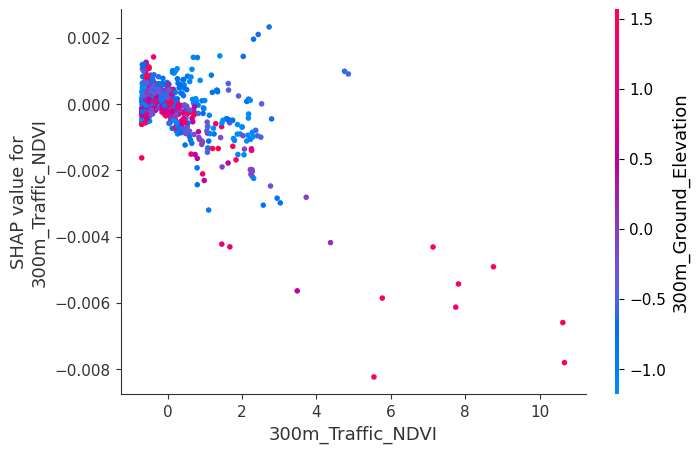

In [29]:
explainer.dependence_plot("300m_Traffic_NDVI")

The SHAP dependence plot for `300m_Traffic_NDVI` explores the interaction between **traffic volume and the Normalized Difference Vegetation Index (NDVI) within a 300m buffer** and its influence on the UHI index predictions. The x-axis represents `300m_Traffic_NDVI`, while the y-axis shows the corresponding SHAP values, indicating how this feature contributes to the model’s UHI predictions.

The plot exhibits a **negative correlation**, meaning that **higher values of `300m_Traffic_NDVI` (indicating areas with more vegetation in high-traffic zones) are associated with lower SHAP values**, suggesting a cooling effect on UHI. This aligns with the expected role of vegetation in mitigating urban heat by providing shade and promoting evapotranspiration, counteracting the warming effects of traffic-related heat emissions. At **low values of `300m_Traffic_NDVI` (near zero or negative values)**, SHAP values remain **closer to zero or slightly positive**, indicating that **areas with minimal vegetation and/or low traffic volume do not significantly reduce UHI and may contribute slightly to heat retention**.

The color gradient represents `300m_Ground_Elevation`, which provides insight into how terrain elevation interacts with traffic and vegetation in influencing UHI. **Higher ground elevation values (red) are more frequently associated with strongly negative SHAP values**, suggesting that **vegetation in elevated areas may be particularly effective at reducing UHI, possibly due to improved air circulation and reduced urban density**. Conversely, **lower elevation values (blue) appear more often in the region of neutral or positive SHAP values**, indicating that **at lower elevations, traffic-related vegetation may have a weaker cooling effect, potentially due to increased urban heat retention**.

Overall, this plot suggests that **the combination of high vegetation and traffic volume within a 300m buffer contributes to cooling effects, reducing UHI intensity**, especially in areas with higher elevation. However, **in low-elevation, high-traffic areas with minimal vegetation, the mitigation effects are weaker, and UHI impacts are more pronounced**. These findings emphasize the importance of **urban greening strategies, particularly in high-traffic areas and lower-elevation zones, to maximize the cooling benefits of vegetation in urban heat island mitigation efforts**. Further analysis could explore **how vegetation density and species type influence the cooling efficiency in varying urban terrains**.

### 150m Traffic Volume

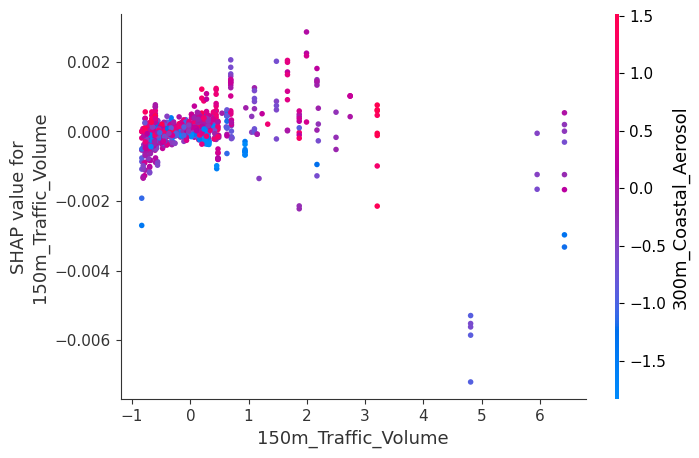

In [30]:
explainer.dependence_plot("150m_Traffic_Volume")

The SHAP dependence plot for `150m_Traffic_Volume` examines the relationship between **traffic density within a 150m buffer** and its impact on the UHI index predictions. The x-axis represents `150m_Traffic_Volume`, while the y-axis shows the corresponding SHAP values, indicating how this feature contributes to the model’s UHI predictions.

The plot suggests a **weak correlation** between `150m_Traffic_Volume` and UHI, as SHAP values remain **tightly clustered around zero** for most of the range. This implies that **traffic volume alone does not significantly drive UHI predictions in the model**. However, at **higher values of `150m_Traffic_Volume` (above 2), there is a greater spread in SHAP values, with some data points showing both positive and negative contributions**, suggesting that in **some high-traffic locations, UHI effects may be amplified, while in others, cooling factors counteract the expected warming**.

At **lower values of `150m_Traffic_Volume` (near zero or negative values)**, SHAP values are mostly neutral, indicating that **low traffic areas do not strongly influence the UHI index**. However, as traffic volume increases beyond **moderate levels (~2+), SHAP values show more variability**, indicating that **some high-traffic areas experience heat retention effects, while others might have mitigating factors such as vegetation, shading, or ventilation effects counteracting UHI**.

The color gradient represents `300m_Coastal_Aerosol`, indicating **the concentration of airborne particles within a 300m buffer**. **Higher `300m_Coastal_Aerosol` values (red) are more common at moderate to high traffic volumes, particularly where SHAP values are positive**, suggesting that **in areas with high air pollution from aerosols, traffic-related heat retention effects may be more pronounced**. Conversely, **lower `300m_Coastal_Aerosol` values (blue) appear more frequently where SHAP values are negative, indicating that in cleaner environments, traffic volume might have a less pronounced impact on UHI**.

Overall, this plot suggests that **traffic volume alone does not consistently drive UHI intensity, but in areas with both high traffic and high aerosol concentration, the heat retention effects may be stronger**. Additionally, the **variability in high-traffic areas indicates that other urban features, such as shading, wind flow, and vegetation, may interact with traffic effects to either amplify or mitigate UHI impacts**. This highlights the importance of **combining traffic management strategies with urban greening and air quality improvements to reduce localized urban heat island effects**. Further analysis could explore **how traffic-related emissions interact with surface materials and urban morphology to refine mitigation strategies in high-traffic areas**.

## Force Plot

Finally, we will explain an individual prediction within the context of an Urban Heat Island (UHI). Additionally, we will develop a reusable function that allows users to understand why a given prediction receives a high or low UHI Index. This function will provide insights into the specific factors influencing the UHI index for a location, highlighting the key local drivers contributing to the result.

In [31]:
#location index
record_index = 1038

#show location
loc_UHI.iloc[record_index, :]

,1038
Longitude,-73.917223
Latitude,40.815413
UHI Index,1.037447


In [32]:
shap.initjs()
explainer.force_plot(index=record_index)

The force plot for the Urban Heat Island (UHI) location **(-73.917223, 40.815413)** provides insight into how various environmental and urban factors influence the model's prediction. The primary contributors to the elevated UHI index include **`300m_Elevation_Wind_Y = 0.9341` and `150m_Elevation_Wind_Y = 0.8423`**, which suggest that **north-south wind dynamics play a role in heat retention rather than dispersion in this location**. Additionally, **`300m_Traffic_NDBI = 0.87`**, which captures traffic density and built-up intensity, contributes to the warming effect, reinforcing the role of urban infrastructure in retaining heat. Another significant factor is **`300m_Building_Wind_X = 0.8949`**, which indicates that east-west wind interactions may be limiting effective heat dissipation.

On the other hand, two features work slightly against the UHI effect but do not fully counteract the heat increase. **`150m_Humidity_NDVI = -1.021`** and **`300m_TotalBuildingArea_NDVI = -0.8103`** indicate the presence of vegetation and humidity, which typically help to mitigate urban heat. However, their influence in this specific case is not strong enough to outweigh the heat-retaining factors.

Overall, this force plot suggests that **while some natural cooling elements are present in the area, the combination of wind flow patterns, traffic-related built-up intensity, and building density contributes to the slightly elevated UHI effect**. For this location this highlights the importance of **strategic urban planning that optimizes wind flow, reduces heat-retaining surfaces, and enhances vegetation coverage to counteract localized urban heating trends**. With this insight, urban planners now have valuable information on how to effectively mitigate the Urban Heat Island effect for this location.

Now let's create a function that can easily be called to get insights like these for other locations.

### Local UHI Explanation Function

This function converts SHAP force plot data into a JSON format, providing the same insights in a structured way. The function takes SHAP values, feature contributions, and record index as input and returns dict with the final prediction, contributing factors, and their impact on the Urban Heat Island (UHI) index. We will add this to our custom `Explainer` class, so users can easily call the function when the object is initialized.

>NOTE: When we add the function to our `Explainer` class we won't need the args `shap_values`, `feature_names`, `y_pred`, and `base_value` because they are already atrributes of the Explainer class.

In [1]:
def reasoning(shap_values, feature_names, y_pred, record_index, base_value=1, location=(None, None)):
    """
    Provides insights on why the record received a high or low UHI index.

    Parameters:
        shap_values (2D list of float): SHAP values for multiple records.
        feature_names (list of str): Corresponding feature names.
        y_pred (list of float): The predicted values for all records.
        record_index (int): The index of the record to retrieve SHAP values.
        base_value (float) (optional): The base value (mean model prediction) (1 for our UHI model).
        location (tuple) (optional): The location of the record (long, lat).

    Returns:
        dict: The insights for the selected record.
    """

    # Validate record index
    if record_index >= len(shap_values) or record_index < 0:
        return {"error": "Invalid record index"}

    # Extract SHAP values for the specified record
    record_shap_values = shap_values[record_index]

    # Extract actual predicted value for the specified record
    predicted_value = y_pred[record_index][0]

    # Compute SHAP-based final prediction
    shap_final_prediction = base_value + sum(record_shap_values)

    # Structure feature contributions
    feature_contributions = [
        {
            "feature": feature,
            "shap_value": value,
            "impact": "increase" if value > 0 else "decrease"
        }
        for feature, value in zip(feature_names, record_shap_values)
    ]

    # Create JSON structure
    shap_json = {
        "record_index": record_index,
        "longitude": location[0],
        "latitude": location[1],
        "base_value": base_value,
        "prediction": predicted_value,  # Model's predicted value
        "shap_final_prediction": shap_final_prediction,  # SHAP-based predicted value
        "uhi_status": "Urban Heat Island" if predicted_value > 1 else "Cooler Region",
        "feature_contributions": feature_contributions,
    }

    return shap_json

>NOTE: We observed that the contribution values in the Force Plot differ from those in our custom function. This is because the SHAP library applies a transformation before displaying the values in the Force Plot, whereas our function does not. However, our custom function directly utilizes the original SHAP values that are used to compute the final SHAP-based prediction. Despite this difference, these original SHAP values still accurately represent each feature's contribution to the final prediction.

In [33]:
reasoning(explainer.shap_values, test_dataset.columns, y_pred, record_index, location=(loc_UHI.iloc[record_index, 0], loc_UHI.iloc[record_index, 1]))

{'record_index': 1038,
 'longitude': -73.91722333,
 'latitude': 40.81541333,
 'base_value': 1,
 'prediction': 1.0374466,
 'shap_final_prediction': 1.0374317969856826,
 'uhi_status': 'Urban Heat Island',
 'feature_contributions': [{'feature': '50m_1NPCRI',
   'shap_value': 0.0021378570248755725,
   'impact': 'increase'},
  {'feature': '100m_Elevation_Wind_X',
   'shap_value': 0.000613184443253036,
   'impact': 'increase'},
  {'feature': '150m_Traffic_Volume',
   'shap_value': 0.0012148725273443857,
   'impact': 'increase'},
  {'feature': '150m_Elevation_Wind_Y',
   'shap_value': 0.002393632754730205,
   'impact': 'increase'},
  {'feature': '150m_Humidity_NDVI',
   'shap_value': 0.00425701072853908,
   'impact': 'increase'},
  {'feature': '150m_Traffic_NDBI',
   'shap_value': -0.0005734185012232842,
   'impact': 'decrease'},
  {'feature': '300m_SI',
   'shap_value': 0.0020904220038045875,
   'impact': 'increase'},
  {'feature': '300m_NPCRI',
   'shap_value': 0.001368060205540325,
   'imp

# Conclusion

Through our SHAP analysis, we gained a comprehensive understanding of how various environmental, structural, and meteorological factors influence Urban Heat Island (UHI) intensity. The SHAP summary plots provided a global view of feature importance, while the dependence plots revealed nuanced relationships between individual features and their interactions. The force plots allowed us to dissect specific predictions, offering clear explanations of how different features contribute to localized urban heat effects.  

Our findings highlight several key drivers of UHI. **Wind-related factors**, such as `300m_Building_Wind_X` and `150m_Elevation_Wind_Y`, were consistent contributors to increased UHI, suggesting that urban airflow dynamics play a crucial role in heat retention. **Traffic-related features**, particularly `300m_Traffic_NDBI`, also had a significant positive impact, indicating that vehicular activity contributes to localized heating. Conversely, **vegetation and building area**—captured through `NDVI`-related features—help mitigate UHI effects by reducing surface and ambient temperatures.  

From an urban planning perspective, these insights offer valuable guidance for mitigating UHI effects. Strategies such as **enhancing green spaces, optimizing building layouts for better airflow, and managing traffic density** can significantly reduce urban heat stress. By leveraging our custom function that uses SHAP-based explainability, policymakers and city planners can make data-driven decisions to design cooler, more sustainable urban environments.  